# DLAV Project - Phase 2

This notebook mirrors the `dlav_phase2.py` script. It includes data loading, model definition, training, visualization, and submission creation.

In [1]:
# Mount Google Drive (optional)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive"
except Exception:
    DRIVE_ROOT = None
    print("Google Drive not available; saving locally.")

Mounted at /content/drive


The first step is to prepare the data. The code below will download the data from Google Drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [2]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = "https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=b0ddaa82-d6bf-41bf-b4a3-718c9adc6143
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:06<00:00, 68.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=8ed65078-2bd7-4aaf-9081-7a57fe41b94f
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:01<00:00, 80.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=14f50e80-3023-43aa-9753-000f3f6ffe1c
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:01<00:00, 72.6MB/s]


In [3]:
# Setup and configuration
import os
import copy
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

CFG = dict(
    # Data
    train_dir="train",
    val_dir="val",
    test_dir="test_public",
    num_workers=2,

    # Model
    degree_coarse=3,
    degree_fine=5,
    num_timesteps=40, #60
    img_feat_dim=512,
    hist_d_model=96, #128
    hist_nhead=4,
    hist_layers=2,
    hist_feat_dim=128,
    cmd_embed_dim=64,
    fusion_dim=192, #256
    dropout=0.2,
    freeze_backbone=4,
    velocity_window=5,
    num_seg_classes=19,

    # Aux task flags
    use_depth=False,
    use_seg=False,

    # Loss weights
    lambda_coarse=0.3,
    lambda_depth=0.05,
    lambda_seg=0.1,

    # Training (Colab T4-friendly defaults)
    batch_size=32, #16
    num_epochs=10, #30
    lr_backbone=1e-4,
    lr_head=1e-3,
    weight_decay=1e-4,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
class DrivingDataset(Dataset):
    """
    Loads each .pkl sample and returns:
      camera   : (3, H, W)  float32, ImageNet-normalized
      history  : (21, 3)    float32  [x, y, heading]
      command  : ()         int64    0=forward, 1=left, 2=right
      future   : (T, 3)     float32  [x, y, heading]  - absent for test
      depth    : (H, W, 1)  float32  - optional
      seg      : (H, W)     int64    - optional
    """
    COMMAND_TO_IDX = {"forward": 0, "left": 1, "right": 2}

    IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    MAX_CROP_TOP = 30
    MAX_HSHIFT = 8

    def __init__(self, file_list, train=False, test=False):
        self.samples = file_list
        self.train = train
        self.test = test

        if train:
            self.color_aug = transforms.Compose([
                transforms.ColorJitter(brightness=0.25, contrast=0.25,
                                       saturation=0.15, hue=0.05),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
                transforms.RandomErasing(p=0.25, scale=(0.02, 0.08),
                                         ratio=(0.3, 3.3), value=0),
            ])
        else:
            self.color_aug = None

    def _random_crop_top(self, img):
        crop = torch.randint(0, self.MAX_CROP_TOP + 1, (1,)).item()
        if crop == 0:
            return img
        cropped = img[:, crop:, :]
        return F.interpolate(cropped.unsqueeze(0), size=(200, 300),
                             mode="bilinear", align_corners=False).squeeze(0)

    def _random_hshift(self, img):
        shift = torch.randint(-self.MAX_HSHIFT, self.MAX_HSHIFT + 1, (1,)).item()
        if shift == 0:
            return img
        shifted = torch.roll(img, shifts=shift, dims=2)
        if shift > 0:
            shifted[:, :, :shift] = 0
        else:
            shifted[:, :, shift:] = 0
        return shifted

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], "rb") as f:
            data = pickle.load(f)

        camera = torch.FloatTensor(data["camera"]).permute(2, 0, 1) / 255.0
        if self.train:
            camera = self._random_crop_top(camera)
            camera = self._random_hshift(camera)
            camera = self.color_aug(camera)
        camera = (camera - self.IMAGENET_MEAN) / self.IMAGENET_STD

        history = torch.FloatTensor(data["sdc_history_feature"])
        command = torch.tensor(
            self.COMMAND_TO_IDX[data["driving_command"]], dtype=torch.long
        )

        sample = {"camera": camera, "history": history, "command": command}

        if not self.test:
            future = torch.FloatTensor(data["sdc_future_feature"])
            t = int(CFG["num_timesteps"])
            sample["future"] = future[:t]

        if "depth" in data:
            sample["depth"] = torch.FloatTensor(data["depth"])
        if "seg" in data:
            sample["seg"] = torch.LongTensor(data["seg"].astype(np.int64))

        return sample

In [5]:
class TransformerHistoryEncoder(nn.Module):
    """
    Encodes (B, 21, 3) -> (B, out_dim) with a Transformer encoder.
    """
    def __init__(self, in_dim=3, d_model=128, nhead=4, num_layers=2,
                 out_dim=128, dropout=0.1, max_len=21):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.out_proj = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, out_dim),
        )

    def forward(self, history):
        b, t, _ = history.shape
        x = self.input_proj(history)
        pos = torch.arange(t, device=history.device)
        x = x + self.pos_embed(pos).unsqueeze(0)

        cls = self.cls_token.expand(b, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.transformer(x)

        return self.out_proj(x[:, 0, :])


class FiLM(nn.Module):
    def __init__(self, cond_dim, feat_dim):
        super().__init__()
        self.to_gamma = nn.Linear(cond_dim, feat_dim)
        self.to_beta = nn.Linear(cond_dim, feat_dim)
        nn.init.zeros_(self.to_gamma.weight)
        nn.init.ones_(self.to_gamma.bias)
        nn.init.zeros_(self.to_beta.weight)
        nn.init.zeros_(self.to_beta.bias)

    def forward(self, x, cond):
        return self.to_gamma(cond) * x + self.to_beta(cond)


class PolynomialTrajectoryDecoder(nn.Module):
    """
    trajectory = linear_prior(history) + polynomial_residual(coeffs)
    """
    def __init__(self, degree=5, num_timesteps=60, velocity_window=5):
        super().__init__()
        self.degree = degree
        self.num_timesteps = num_timesteps
        self.velocity_window = velocity_window

        t = torch.linspace(0, 1, num_timesteps)
        v = torch.stack([t ** (k + 1) for k in range(degree)], dim=1)
        self.register_buffer("V", v)

        t_lin = torch.arange(1, num_timesteps + 1, dtype=torch.float32)
        self.register_buffer("t_linear", t_lin)

    def compute_prior(self, history):
        k = self.velocity_window
        past_pos = history[:, -1 - k, :2]
        vel = -past_pos / k
        prior = self.t_linear.view(1, -1, 1) * vel.unsqueeze(1)
        return prior

    def forward(self, coeffs, history):
        prior = self.compute_prior(history)
        residual = torch.einsum("tk,bak->bta", self.V, coeffs)
        return prior + residual


class CoarseToFineDecoder(nn.Module):
    def __init__(self, fusion_dim, degree_coarse=3, degree_fine=5,
                 num_timesteps=60, velocity_window=5, dropout=0.1):
        super().__init__()
        self.T = num_timesteps

        self.coarse_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 2 * degree_coarse),
        )
        self.coarse_decoder = PolynomialTrajectoryDecoder(
            degree_coarse, num_timesteps, velocity_window)

        self.coarse_enc = nn.Sequential(
            nn.Linear(num_timesteps * 2, 64), nn.ReLU(),
        )
        self.fine_head = nn.Sequential(
            nn.Linear(fusion_dim + 64, fusion_dim // 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 2 * degree_fine),
        )
        self.fine_decoder = PolynomialTrajectoryDecoder(
            degree_fine, num_timesteps, velocity_window)

        nn.init.zeros_(self.coarse_head[-1].weight)
        nn.init.zeros_(self.coarse_head[-1].bias)
        nn.init.zeros_(self.fine_head[-1].weight)
        nn.init.zeros_(self.fine_head[-1].bias)

    def forward(self, latent, history):
        b = latent.size(0)

        coarse_coeffs = self.coarse_head(latent).view(b, 2, -1)
        coarse_traj = self.coarse_decoder(coarse_coeffs, history)

        coarse_enc = self.coarse_enc(coarse_traj.view(b, -1))
        fine_input = torch.cat([latent, coarse_enc], dim=1)
        fine_coeffs = self.fine_head(fine_input).view(b, 2, -1)
        fine_residual = self.fine_decoder(fine_coeffs, history)

        fine_traj = coarse_traj + fine_residual
        return coarse_traj, fine_traj


def build_aux_decoder(in_channels, out_channels, target_size=(200, 300)):
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, 256, 4, stride=2, padding=1), nn.ReLU(inplace=True),
        nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.ReLU(inplace=True),
        nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(inplace=True),
        nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(32, out_channels, 3, padding=1),
        nn.Upsample(size=target_size, mode="bilinear", align_corners=False),
    )

In [6]:
class DrivingPlannerV2(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.use_depth = cfg["use_depth"]
        self.use_seg = cfg["use_seg"]

        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.stage0 = nn.Sequential(*list(resnet.children())[:5])
        self.stage1 = resnet.layer2
        self.stage2 = resnet.layer3
        self.stage3 = resnet.layer4
        self.gap = nn.AdaptiveAvgPool2d(1)
        self._freeze_stages(cfg["freeze_backbone"])

        self.history_encoder = TransformerHistoryEncoder(
            in_dim=3,
            d_model=cfg["hist_d_model"],
            nhead=cfg["hist_nhead"],
            num_layers=cfg["hist_layers"],
            out_dim=cfg["hist_feat_dim"],
            dropout=cfg["dropout"],
        )

        ced = cfg["cmd_embed_dim"]
        self.command_embedding = nn.Embedding(3, ced)
        self.command_mlp = nn.Sequential(
            nn.Linear(ced, ced), nn.ReLU(inplace=True), nn.Linear(ced, ced),
        )

        in_dim = cfg["img_feat_dim"] + cfg["hist_feat_dim"]
        fd = cfg["fusion_dim"]
        self.fusion = nn.Sequential(
            nn.Linear(in_dim, fd), nn.ReLU(inplace=True), nn.Dropout(cfg["dropout"]),
            nn.Linear(fd, fd), nn.ReLU(inplace=True), nn.Dropout(cfg["dropout"]),
        )
        self.film = FiLM(cond_dim=ced, feat_dim=fd)

        self.traj_decoder = CoarseToFineDecoder(
            fusion_dim=fd + ced,
            degree_coarse=cfg["degree_coarse"],
            degree_fine=cfg["degree_fine"],
            num_timesteps=cfg["num_timesteps"],
            velocity_window=cfg["velocity_window"],
            dropout=cfg["dropout"],
        )

        if self.use_depth:
            self.depth_decoder = build_aux_decoder(512, 1)
        if self.use_seg:
            self.seg_decoder = build_aux_decoder(512, cfg["num_seg_classes"])

    def _freeze_stages(self, n):
        boundaries = {1: 5, 2: 6, 3: 7, 4: 8}
        limit = boundaries.get(n, 0)
        for i, child in enumerate(
            [self.stage0, self.stage1, self.stage2, self.stage3]
        ):
            if i < limit:
                for p in child.parameters():
                    p.requires_grad = False

    def get_param_groups(self, lr_backbone, lr_head, weight_decay):
        backbone_params = [
            p for stage in [self.stage0, self.stage1, self.stage2, self.stage3]
            for p in stage.parameters() if p.requires_grad
        ]
        head_modules = [
            self.gap, self.history_encoder,
            self.command_embedding, self.command_mlp,
            self.fusion, self.film, self.traj_decoder,
        ]
        if self.use_depth:
            head_modules.append(self.depth_decoder)
        if self.use_seg:
            head_modules.append(self.seg_decoder)
        head_params = [p for m in head_modules for p in m.parameters()]
        return [
            {"params": backbone_params, "lr": lr_backbone, "weight_decay": weight_decay},
            {"params": head_params, "lr": lr_head, "weight_decay": weight_decay},
        ]

    def forward(self, camera, history, command):
        f0 = self.stage0(camera)
        f1 = self.stage1(f0)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)

        feat_img = self.gap(f3).flatten(1)
        feat_hist = self.history_encoder(history)
        feat_cmd = self.command_mlp(self.command_embedding(command))

        fused = self.fusion(torch.cat([feat_img, feat_hist], dim=1))
        latent = self.film(fused, feat_cmd)

        latent_with_cmd = torch.cat([latent, feat_cmd], dim=1)
        coarse_traj, fine_traj = self.traj_decoder(latent_with_cmd, history)

        depth_out = torch.sigmoid(self.depth_decoder(f3)) if self.use_depth else None
        seg_out = self.seg_decoder(f3) if self.use_seg else None

        return fine_traj, coarse_traj, depth_out, seg_out

In [7]:
def smooth_trajectory(traj, degree=3, num_timesteps=60):
    """
    Fit a low-degree polynomial to the GT trajectory to create a smooth target.
    """
    b, t, _ = traj.shape
    _ = num_timesteps
    t_np = np.linspace(0, 1, t)
    smooth_np = np.zeros_like(traj.detach().cpu().numpy())
    traj_np = traj.detach().cpu().numpy()
    for bi in range(b):
        for ax in range(2):
            c = np.polyfit(t_np, traj_np[bi, :, ax], deg=degree)
            smooth_np[bi, :, ax] = np.polyval(c, t_np)
    return torch.tensor(smooth_np, dtype=traj.dtype, device=traj.device)


def compute_loss(fine_traj, coarse_traj, depth_out, seg_out,
                 batch, cfg, device):
    gt_future = batch["future"].to(device)[..., :2]

    traj_loss = F.mse_loss(fine_traj, gt_future)
    smooth_gt = smooth_trajectory(gt_future, degree=cfg["degree_coarse"])
    coarse_loss = F.mse_loss(coarse_traj, smooth_gt)

    total = traj_loss + cfg["lambda_coarse"] * coarse_loss
    log = {"traj": traj_loss.item(), "coarse": coarse_loss.item()}

    if depth_out is not None and "depth" in batch:
        gt_depth = batch["depth"].to(device)
        gt_depth = gt_depth.permute(0, 3, 1, 2)
        d_max = gt_depth.flatten(1).max(1)[0].view(-1, 1, 1, 1).clamp(min=1e-3)
        gt_depth = gt_depth / d_max
        depth_loss = F.l1_loss(depth_out, gt_depth)
        total = total + cfg["lambda_depth"] * depth_loss
        log["depth"] = depth_loss.item()

    if seg_out is not None and "seg" in batch:
        gt_seg = batch["seg"].to(device)
        seg_loss = F.cross_entropy(seg_out, gt_seg, ignore_index=255)
        total = total + cfg["lambda_seg"] * seg_loss
        log["seg"] = seg_loss.item()

    log["total"] = total.item()
    return total, log


def compute_ade_fde(pred, gt):
    diff = pred - gt[..., :2]
    dist = torch.norm(diff, p=2, dim=-1)
    ade = dist.mean(dim=1).mean().item()
    fde = dist[:, -1].mean().item()
    return ade, fde

In [8]:
def train(model, train_loader, val_loader, optimizer, scheduler, cfg):
    model = model.to(DEVICE)

    best_ade = float("inf")
    best_state_dict = None
    best_epoch = -1
    history_log = {"train_total": [], "val_ade": [], "val_fde": [], "lr": []}

    for epoch in range(cfg["num_epochs"]):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            camera = batch["camera"].to(DEVICE)
            history = batch["history"].to(DEVICE)
            command = batch["command"].to(DEVICE)

            optimizer.zero_grad()
            fine_traj, coarse_traj, depth_out, seg_out = model(camera, history, command)
            loss, _ = compute_loss(fine_traj, coarse_traj, depth_out, seg_out,
                                   batch, cfg, DEVICE)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)

        model.eval()
        ade_all, fde_all = [], []
        with torch.no_grad():
            for batch in val_loader:
                camera = batch["camera"].to(DEVICE)
                history = batch["history"].to(DEVICE)
                command = batch["command"].to(DEVICE)
                future = batch["future"].to(DEVICE)

                fine_traj, *_ = model(camera, history, command)
                ade, fde = compute_ade_fde(fine_traj, future)
                ade_all.append(ade)
                fde_all.append(fde)

        mean_ade = float(np.mean(ade_all))
        mean_fde = float(np.mean(fde_all))

        current_lr = optimizer.param_groups[0]["lr"]
        if scheduler is not None:
            scheduler.step()

        history_log["train_total"].append(epoch_loss)
        history_log["val_ade"].append(mean_ade)
        history_log["val_fde"].append(mean_fde)
        history_log["lr"].append(current_lr)

        is_best = mean_ade < best_ade
        if is_best:
            best_ade = mean_ade
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict())

        marker = " *" if is_best else ""
        print(
            f"Epoch {epoch + 1:3d}/{cfg['num_epochs']} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Val ADE: {mean_ade:.4f} | FDE: {mean_fde:.4f} | "
            f"LR: {current_lr:.1e}{marker}"
        )

    print(f"Best ADE: {best_ade:.4f} at epoch {best_epoch}")
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    return model, history_log, best_ade

In [9]:
IMAGENET_MEAN_NP = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
IMAGENET_STD_NP = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)


def denorm(img_tensor):
    img = img_tensor.numpy() * IMAGENET_STD_NP + IMAGENET_MEAN_NP
    return np.clip(img.transpose(1, 2, 0), 0, 1)


def visualize(model, val_loader, k=4):
    model.eval()
    batch = next(iter(val_loader))
    camera = batch["camera"].to(DEVICE)
    history = batch["history"].to(DEVICE)
    command = batch["command"].to(DEVICE)
    future = batch["future"]

    with torch.no_grad():
        fine_traj, coarse_traj, depth_out, seg_out = model(camera, history, command)

    cam_np = camera.cpu()
    hist_np = history.cpu().numpy()
    fut_np = future.numpy()
    fine_np = fine_traj.cpu().numpy()
    coarse_np = coarse_traj.cpu().numpy()

    indices = random.choices(range(len(cam_np)), k=k)

    fig, axes = plt.subplots(1, k, figsize=(4 * k, 4))
    for i, idx in enumerate(indices):
        axes[i].imshow(denorm(cam_np[idx]))
        axes[i].axis("off")
        axes[i].set_title(f"Example {i + 1}")
    plt.suptitle("Camera Inputs")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, k, figsize=(4 * k, 4))
    for i, idx in enumerate(indices):
        axes[i].plot(hist_np[idx, :, 0], hist_np[idx, :, 1],
                     "o-", color="gold", markersize=4, label="Past")
        axes[i].plot(fut_np[idx, :, 0], fut_np[idx, :, 1],
                     "o-", color="green", markersize=4, label="GT")
        axes[i].plot(coarse_np[idx, :, 0], coarse_np[idx, :, 1],
                     "--", color="orange", markersize=3, label="Coarse")
        axes[i].plot(fine_np[idx, :, 0], fine_np[idx, :, 1],
                     "o-", color="red", markersize=3, label="Fine")
        axes[i].legend(fontsize=7)
        axes[i].axis("equal")
        axes[i].grid(alpha=0.3)
    plt.suptitle("Trajectory: GT vs Coarse vs Fine")
    plt.tight_layout()
    plt.show()

    if depth_out is not None and "depth" in batch:
        dep_pred_np = depth_out.cpu().numpy()
        dep_gt_np = batch["depth"].numpy()
        fig, axes = plt.subplots(2, k, figsize=(4 * k, 6))
        for i, idx in enumerate(indices):
            axes[0, i].imshow(dep_gt_np[idx, :, :, 0], cmap="viridis")
            axes[0, i].set_title("GT Depth")
            axes[0, i].axis("off")
            axes[1, i].imshow(dep_pred_np[idx, 0, :, :], cmap="viridis")
            axes[1, i].set_title("Pred Depth")
            axes[1, i].axis("off")
        plt.suptitle("Depth Estimation")
        plt.tight_layout()
        plt.show()

    if seg_out is not None and "seg" in batch:
        seg_pred_np = seg_out.argmax(1).cpu().numpy()
        seg_gt_np = batch["seg"].numpy()
        fig, axes = plt.subplots(2, k, figsize=(4 * k, 6))
        for i, idx in enumerate(indices):
            axes[0, i].imshow(seg_gt_np[idx], cmap="tab20")
            axes[0, i].set_title("GT Seg")
            axes[0, i].axis("off")
            axes[1, i].imshow(seg_pred_np[idx], cmap="tab20")
            axes[1, i].set_title("Pred Seg")
            axes[1, i].axis("off")
        plt.suptitle("Segmentation")
        plt.tight_layout()
        plt.show()

In [10]:
def make_submission(model, cfg, filename="submission_phase2.csv"):
    test_dir = cfg["test_dir"]
    test_files = [
        os.path.join(test_dir, fn)
        for fn in sorted(
            [f for f in os.listdir(test_dir) if f.endswith(".pkl")],
            key=lambda fn: int(os.path.splitext(fn)[0]),
        )
    ]
    test_dataset = DrivingDataset(test_files, train=False, test=True)
    test_loader = DataLoader(test_dataset, batch_size=250,
                             num_workers=cfg["num_workers"])

    model.eval()
    all_plans = []
    with torch.no_grad():
        for batch in test_loader:
            camera = batch["camera"].to(DEVICE)
            history = batch["history"].to(DEVICE)
            command = batch["command"].to(DEVICE)
            fine_traj, *_ = model(camera, history, command)
            all_plans.append(fine_traj.cpu().numpy()[..., :2])

    all_plans = np.concatenate(all_plans, axis=0)
    n, t, _ = all_plans.shape
    flat = all_plans.reshape(n, t * 2)

    cols = ["id"] + [f"{ax}_{t + 1}" for t in range(t) for ax in ("x", "y")]
    df = pd.DataFrame(
        np.hstack([np.arange(n).reshape(-1, 1), flat]),
        columns=cols,
    )
    df["id"] = df["id"].astype(int)
    df.to_csv(filename, index=False)
    print(f"Saved {filename} ({n} samples, {t} timesteps)")
    return df

Train: 5000 samples | Val: 1000 samples
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]
/tmp/ipykernel_5581/3532620074.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Params total: 11,690,128 | Trainable: 513,616
Epoch   1/10 | Train Loss: 11.9401 | Val ADE: 1.7733 | FDE: 4.2474 | LR: 1.0e-04 *
Epoch   2/10 | Train Loss: 4.9382 | Val ADE: 1.5224 | FDE: 4.0150 | LR: 9.8e-05 *
Epoch   3/10 | Train Loss: 4.3862 | Val ADE: 1.3961 | FDE: 3.6073 | LR: 9.1e-05 *
Epoch   4/10 | Train Loss: 3.9195 | Val ADE: 1.3703 | FDE: 3.5671 | LR: 8.0e-05 *
Epoch   5/10 | Train Loss: 3.6557 | Val ADE: 1.2481 | FDE: 3.2245 | LR: 6.6e-05 *
Epoch   6/10 | Train Loss: 3.3583 | Val ADE: 1.2844 | FDE: 3.3141 | LR: 5.1e-05
Epoch   7/10 | Train Loss: 3.3353 | Val ADE: 1.2677 | FDE: 3.3535 | LR: 3.5e-05
Epoch   8/10 | Train Loss: 3.2642 | Val ADE: 1.1901 | FDE: 3.0722 | LR: 2.1e-05 *
Epoch   9/10 | Train Loss: 3.0353 | Val ADE: 1.1697 | FDE: 3.0225 | LR: 1.0e-05 *
Epoch  10/10 | Train Loss: 3.0135 | Val ADE: 1.1619 | FDE: 3.0130 | LR: 3.4e-06 *
Best ADE: 1.1619 at epoch 10
Final best val ADE: 1.1619


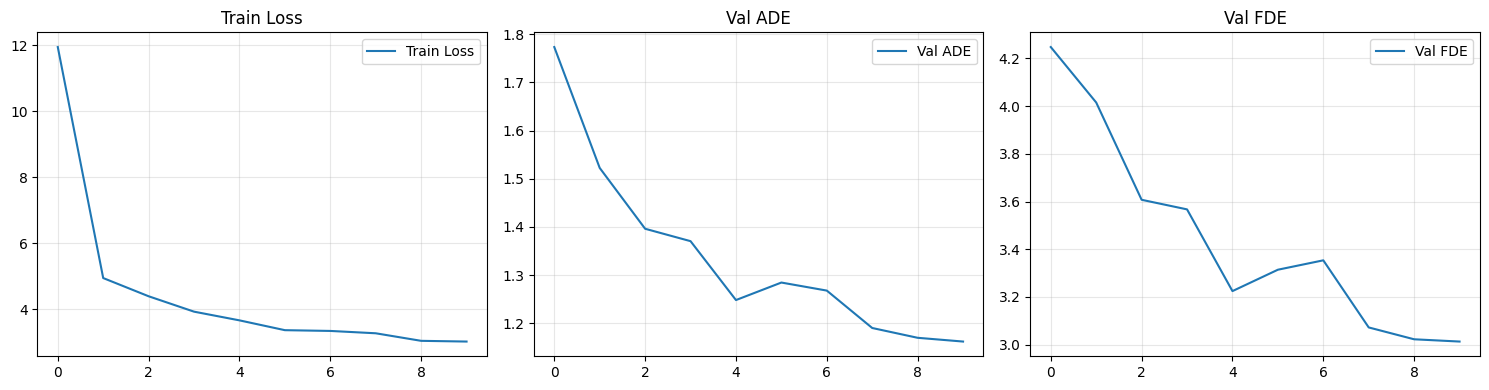

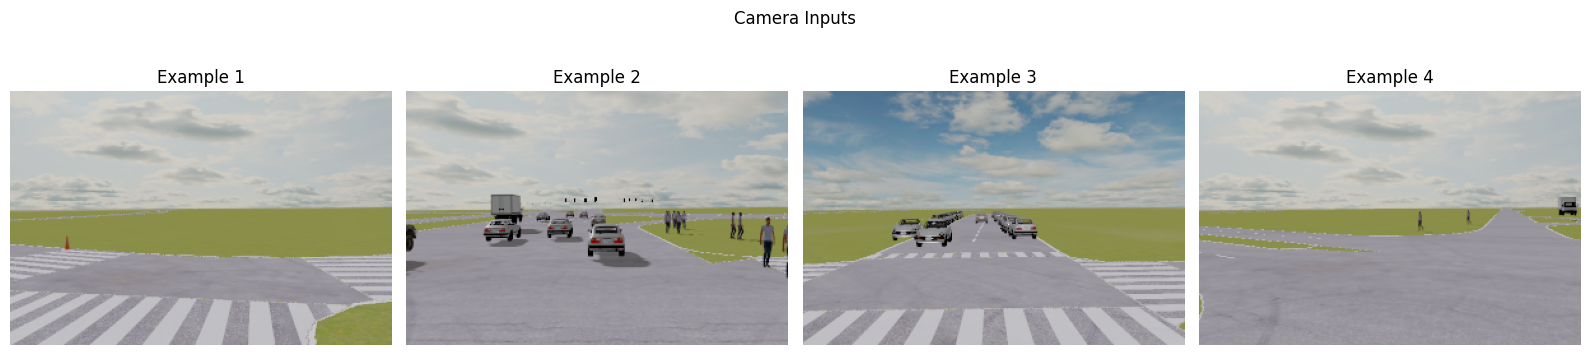

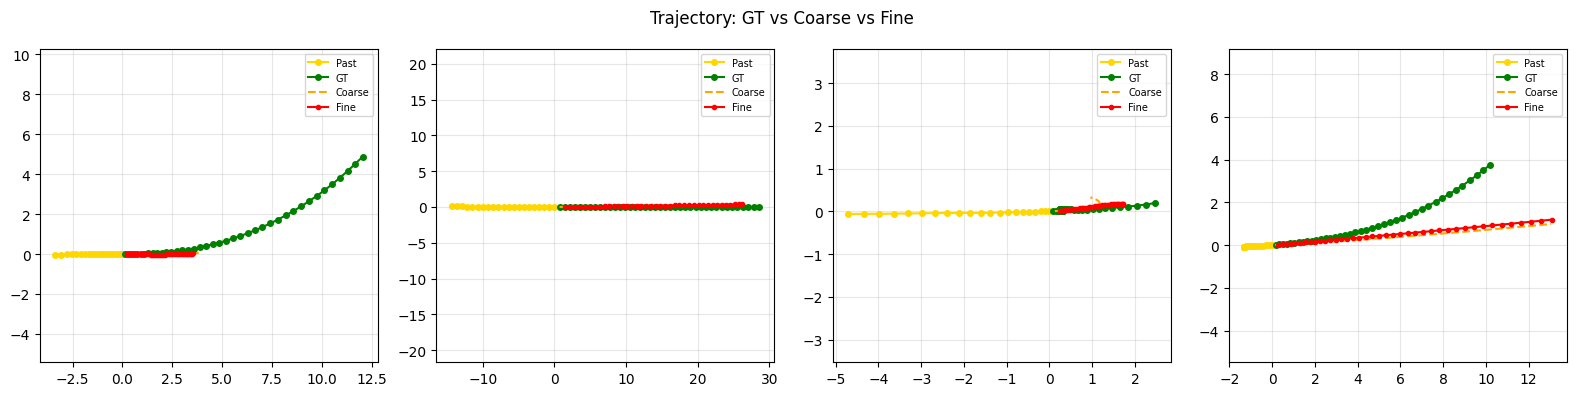

Saved submission_phase2.csv (1000 samples, 40 timesteps)
Checkpoint saved: best_model_phase2.pt
Copied to Drive: /content/drive/MyDrive/submission_phase2.csv
Copied to Drive: /content/drive/MyDrive/best_model_phase2.pt


(DrivingPlannerV2(
   (stage0): Sequential(
     (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
     (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
     (4): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu): ReLU(inplace=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       )
       (1): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [11]:
def main():
    train_files = [
        os.path.join(CFG["train_dir"], f)
        for f in os.listdir(CFG["train_dir"]) if f.endswith(".pkl")
    ]
    val_files = [
        os.path.join(CFG["val_dir"], f)
        for f in os.listdir(CFG["val_dir"]) if f.endswith(".pkl")
    ]
    print(f"Train: {len(train_files)} samples | Val: {len(val_files)} samples")

    train_dataset = DrivingDataset(train_files, train=True)
    val_dataset = DrivingDataset(val_files, train=False)

    train_loader = DataLoader(
        train_dataset, batch_size=CFG["batch_size"],
        num_workers=CFG["num_workers"], shuffle=True,
        pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=CFG["batch_size"],
        num_workers=CFG["num_workers"], shuffle=False,
        pin_memory=True,
    )

    model = DrivingPlannerV2(CFG)
    n_total = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params total: {n_total:,} | Trainable: {n_trainable:,}")

    param_groups = model.get_param_groups(
        lr_backbone=CFG["lr_backbone"],
        lr_head=CFG["lr_head"],
        weight_decay=CFG["weight_decay"],
    )
    optimizer = optim.AdamW(param_groups)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["num_epochs"], eta_min=1e-6,
    )

    model, history_log, best_ade = train(
        model, train_loader, val_loader, optimizer, scheduler, CFG,
    )
    print(f"Final best val ADE: {best_ade:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history_log["train_total"], label="Train Loss")
    axes[0].set_title("Train Loss")
    axes[0].grid(alpha=0.3)
    axes[1].plot(history_log["val_ade"], label="Val ADE")
    axes[1].set_title("Val ADE")
    axes[1].grid(alpha=0.3)
    axes[2].plot(history_log["val_fde"], label="Val FDE")
    axes[2].set_title("Val FDE")
    axes[2].grid(alpha=0.3)
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()

    visualize(model, val_loader, k=4)

    submission_name = "submission_phase2.csv"
    make_submission(model, CFG, filename=submission_name)

    checkpoint_name = "best_model_phase2.pt"
    torch.save(model.state_dict(), checkpoint_name)
    print(f"Checkpoint saved: {checkpoint_name}")

    if DRIVE_ROOT:
        drive_submission = os.path.join(DRIVE_ROOT, submission_name)
        drive_checkpoint = os.path.join(DRIVE_ROOT, checkpoint_name)
        if os.path.isdir(DRIVE_ROOT):
            import shutil
            shutil.copy2(submission_name, drive_submission)
            shutil.copy2(checkpoint_name, drive_checkpoint)
            print(f"Copied to Drive: {drive_submission}")
            print(f"Copied to Drive: {drive_checkpoint}")

    return model, history_log


# Run the full pipeline
main()